# Advanced Statistical and Mathematical Methods: Summative 2

## Section 1: Importing Data

In [175]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Telco_customer_churn.xlsx"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yeanzc/telco-customer-churn-ibm-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/var/folders/5d/_70z8cj573dcc1vb6ywm64fh0000gn/T/ipykernel_1388/2258955579.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [176]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Section 2: Data Cleansing

In [177]:
df.shape

(7043, 33)

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Notes from this: zip code doesn't necessarily need to be a int, calculations should not be done on it, total charges should be a float, suggests data errors

In [179]:
df['Zip Code'] = df['Zip Code'].astype(object)

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   object 
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [181]:
import pandas as pd

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [182]:
# Checking for null values
df.isnull().any()

CustomerID           False
Count                False
Country              False
State                False
City                 False
Zip Code             False
Lat Long             False
Latitude             False
Longitude            False
Gender               False
Senior Citizen       False
Partner              False
Dependents           False
Tenure Months        False
Phone Service        False
Multiple Lines       False
Internet Service     False
Online Security      False
Online Backup        False
Device Protection    False
Tech Support         False
Streaming TV         False
Streaming Movies     False
Contract             False
Paperless Billing    False
Payment Method       False
Monthly Charges      False
Total Charges         True
Churn Label          False
Churn Value          False
Churn Score          False
CLTV                 False
Churn Reason          True
dtype: bool

Only null value is in churn reason, this is expected as this should be blank for active customers

In [183]:
# View all rows where TotalCharges is null
null_rows = df[df['Total Charges'].isnull()]
print(f"Number of null rows: {len(null_rows)}")
null_rows

Number of null rows: 11


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [184]:
# Map contract type to number of months
contract_months = {
    'Month-to-Month': 1,
    'One year': 12,
    'Two year': 24
}

# Fill missing TotalCharges = MonthlyCharges * contract length
df['Total Charges'] = df.apply(
    lambda row: row['Monthly Charges'] * contract_months[row['Contract']]
    if pd.isnull(row['Total Charges'])
    else row['Total Charges'],
    axis=1
)

# Verify no nulls remain
print(df['Total Charges'].isnull().sum())

0


In [185]:
# Checking for duplicated records that could skew analysis
df.duplicated(subset=None).any().sum()

0

No duplicated rows so all customers are unique

In [186]:
# Convert all column names to lowercase with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Verify
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   object 
 1   count              7043 non-null   int64  
 2   country            7043 non-null   object 
 3   state              7043 non-null   object 
 4   city               7043 non-null   object 
 5   zip_code           7043 non-null   object 
 6   lat_long           7043 non-null   object 
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   object 
 10  senior_citizen     7043 non-null   object 
 11  partner            7043 non-null   object 
 12  dependents         7043 non-null   object 
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   object 
 15  multiple_lines     7043 non-null   object 
 16  internet_service   7043 

In [187]:
df.drop(columns=['customerid','count', 'lat_long', 'churn_reason', 'country', 'state'], inplace=True)

country and state are removed as they are all in California, USA

In [188]:
print(df['churn_label'].value_counts(normalize=True))

churn_label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [189]:
numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges', 'churn_score', 'cltv']
df[numeric_cols].describe()

,tenure_months,monthly_charges,total_charges,churn_score,cltv
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.253259,58.699418,4400.295755
std,24.559481,30.090047,2265.703526,21.525131,1183.057152
min,0.000000,18.250000,18.800000,5.000000,2003.000000
25%,9.000000,35.500000,401.900000,40.000000,3469.000000
50%,29.000000,70.350000,1396.250000,61.000000,4527.000000
75%,55.000000,89.850000,3786.600000,75.000000,5380.500000
max,72.000000,118.750000,8684.800000,100.000000,6500.000000


No obvious errors in terms of impossible values (e.g. tenure < 0). Next check for outliers using IQR

In [190]:
def remove_outliers_iqr(frame, cols):
    clean = frame.copy()
    total_before = len(clean)

    for col in cols:
        # ensure numeric
        clean[col] = pd.to_numeric(clean[col], errors="coerce")

        Q1 = clean[col].quantile(0.25)
        Q3 = clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        lower_clamped = max(lower, 0)

        mask_out = (clean[col] < lower_clamped) | (clean[col] > upper)
        out_count = int(mask_out.sum())

        print(f"{col}: lower={lower_clamped:.3f}, upper={upper:.3f}, outliers={out_count}")

        # Keep only rows that are NOT outliers for this column
        clean = clean.loc[~mask_out]

    print(f"Rows before: {total_before}, after: {len(clean)}, removed: {total_before - len(clean)}")
    return clean

# Use the numeric columns you want to trim
iqr_cols = [c for c in numeric_cols]  # your existing list
df = remove_outliers_iqr(df, iqr_cols)
df = df.reset_index(drop=True)

tenure_months: lower=0.000, upper=124.000, outliers=0
monthly_charges: lower=0.000, upper=171.375, outliers=0
total_charges: lower=0.000, upper=8863.650, outliers=0
churn_score: lower=0.000, upper=127.500, outliers=0
cltv: lower=601.750, upper=8247.750, outliers=0
Rows before: 7043, after: 7043, removed: 0


No values are outside the permitted range so all rows are kept

## Section 3: Data Preparation

In [191]:
product_cols = [
    'phone_service', 'multiple_lines', 'internet_service', 
    'online_security', 'online_backup', 'device_protection', 
    'tech_support', 'streaming_tv', 'streaming_movies'
]

# Standardise product columns to Yes/No only
df['multiple_lines'] = df['multiple_lines'].replace('No phone service', 'No')
df['internet_service'] = df['internet_service'].replace({'DSL': 'Yes', 'Fiber optic': 'Yes'})

# Replace 'No internet service' with 'No' for all affected columns
no_internet_cols = [
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies'
]
for col in no_internet_cols:
    df[col] = df[col].replace('No internet service', 'No')

# Verify
for col in product_cols:
    print(f"{col}: {df[col].unique()}")

phone_service: ['Yes' 'No']
multiple_lines: ['No' 'Yes']
internet_service: ['Yes' 'No']
online_security: ['Yes' 'No']
online_backup: ['Yes' 'No']
device_protection: ['No' 'Yes']
tech_support: ['No' 'Yes']
streaming_tv: ['No' 'Yes']
streaming_movies: ['No' 'Yes']


In [192]:
df['product_count'] = (df[product_cols] == 'Yes').sum(axis=1)

print(df['product_count'].value_counts().sort_index())

product_count
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64


#### Validating other categorical values

In [193]:
non_product_categories = ['gender', 'senior_citizen', 'partner', 'dependents', 'paperless_billing', 'contract', 'payment_method']

for col in non_product_categories:
    print(f"{col}: {df[col].unique()}")

gender: ['Male' 'Female']
senior_citizen: ['No' 'Yes']
partner: ['No' 'Yes']
dependents: ['No' 'Yes']
paperless_billing: ['Yes' 'No']
contract: ['Month-to-month' 'Two year' 'One year']
payment_method: ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


All standardised i.e. no typos, capitalisation inconsistencies or unexpected categories. Data is clean

## Section 4: Exploratory Data Analysis

In the EDA below, the dataset was assessed to ensure that it was suitable for one-way ANOVA exploring the relationship between product portfolio size and churn risk. 

The dependent variable, churn score, is assessed before constructing and evaluating the independent variable - portfolio size.

To improve our wider understanding of the dataset, additional visualisations exploring product diversity, churn risk, customer lifetime value (cltv) and geographic dsitribution are created.

In the code below a colour palette is set for all seaborn charts that is legible for colourblind users, making this project more accessible. The OKABE-ITO colour palette was designed by Masataka Okabe (Jikei Medical School) and Kei Ito (University of Tokyo) (Siegal Lab, n.d.)

In [194]:
import seaborn as sns
import matplotlib as mpl

OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
             "#0072B2", "#D55E00", "#CC79A7", "#000000"]

sns.set_palette(OKABE_ITO)
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=OKABE_ITO)

### Section 4a: Evaluation of Churn Score Distribution

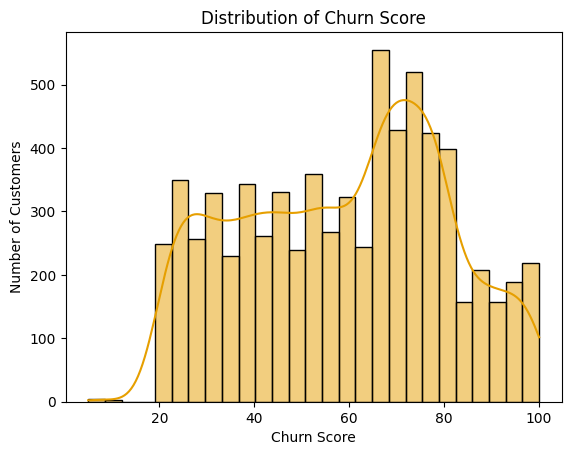

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.histplot(df["churn_score"], kde=True)
plt.title("Distribution of Churn Score")
plt.xlabel("Churn Score")
plt.ylabel("Number of Customers")
plt.show()

This graph shows that we have a broad distribution of churn scores from 20 - 100, with the highest concentration of customers between approximately 65 and 80. This indicates that the dataset contains meaningful variation in churn risk which will allow us to assess it thoroughly against product diveristy groups.

The distribution of churn score deviates somewhat from normality. However, ANOVA is generally considered robust to moderate violations of the normality assumption, particularly when sample sizes are large and group sizes are reasonably balanced. This robustness is partly attributable to the Central Limit Theorem, under which sampling distributions of means tend towards normality as sample size increases (Bühner, 2010). To ensure suitability, the skew is quantified and a Q-Q Plot is created below.

In [196]:
print(df['churn_score'].skew())

-0.08983998912005314


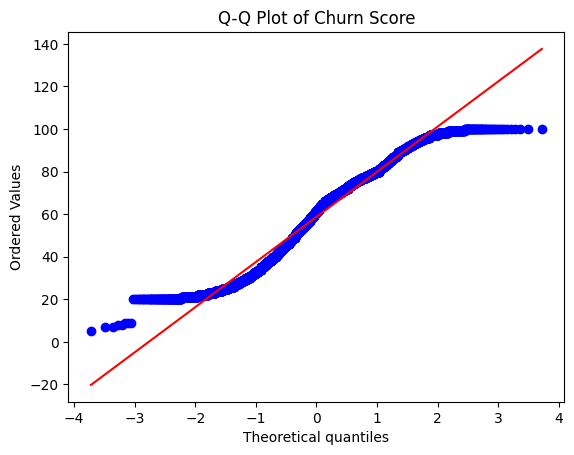

In [197]:
from scipy import stats

stats.probplot(df['churn_score'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Churn Score")
plt.show()

The Q-Q plot indicates moderate deviations from normality at the lower and upper tails, where the observed values depart from the theoretical normal line. However, the central portion of the distribution follows the reference line reasonably closely. Together with the low skewness value (-0.09) and large sample size, the distribution can be considered approximately symmetric, although not perfectly normally distributed, making it still appropriate for ANOVA.

### Section 4b: Distribution of Product Portfolio count

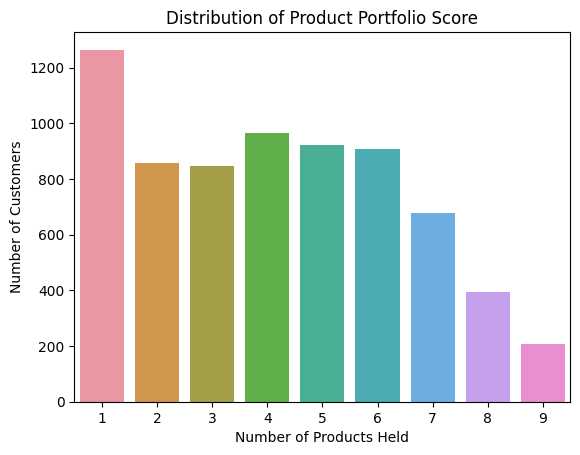

In [198]:
sns.countplot(x="product_count", data=df)
plt.title("Distribution of Product Portfolio Score")
plt.xlabel("Number of Products Held")
plt.ylabel("Number of Customers")
plt.show()

The countplot above shows the number of customers with a certain amount of products with the company. There seems to be a good distribution of customers in the dataset, with less customers at the higher end of the spectrum, which was expected, as was a larger number of customers with only 1 product.

This suggests customers are likely to 'try out' the company with one product at first, before adding multiple add-on services (e.g. a user who adds TV streaming would likely purchase movies as well), explaining why 2/3 products is less popular as loyalty is won and then expanded upon.

This variation will allow us to create the groupings required for high-quality ANOVA in the next step.

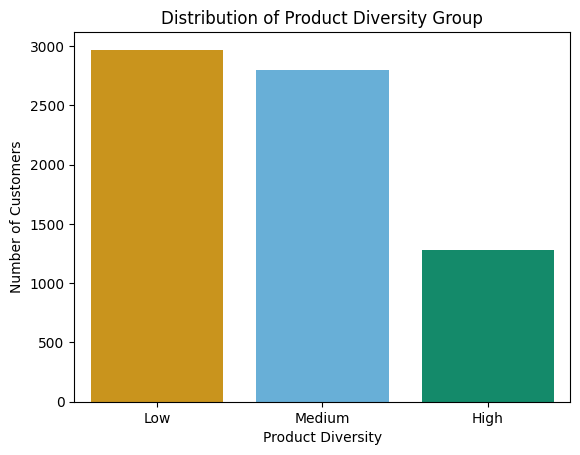

In [199]:
df['product_diversity'] = pd.cut(
    df['product_count'],
    bins=[0, 3, 6, 9],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

sns.countplot(x='product_diversity', data=df, order=['Low', 'Medium', 'High'])
plt.title("Distribution of Product Diversity Group")
plt.xlabel("Product Diversity")
plt.ylabel("Number of Customers")
plt.show()

After reviewing the initial chart in this section, I decided to make the splits for each group as follows:

Low: 1-3 products

Medium: 4-6 products

High: 7-9 products

After creating these groups and displaying them in the graph above, we see approximately equal sized groups for low and medium and a smaller group for high, representing the patterns that we saw in the initial chart.

In [220]:
desc = (
    df.groupby('product_diversity', observed=True)['churn_score']
    .agg(
        Customers='count',
        Mean='mean',
        Median='median',
        SD='std',
        Min='min',
        Max='max'
    )
    .reindex(['Low', 'Medium', 'High'])
    .round(2)
)

desc

,Customers,Mean,Median,SD,Min,Max
product_diversity,,,,,,
Low,2969,58.67,61.0,21.51,8,100
Medium,2795,60.03,64.0,21.81,7,100
High,1279,55.84,56.0,20.66,5,100


The table above summarises the distribution of churn score within each product diversity group.

The High group has the lowest mean (55.84) and median (56.0) churn score, suggesting customers with a broader product portfolio may be associated with lower churn risk. The Medium group has the highest mean (60.03) and median (61.0), while the Low group sits between the two.

The standard deviations are broadly similar across all three groups (~21), indicating comparable spread and supporting the homogeneity of variance assumption that will be formally tested in Section 4f. The means and medians are close within each group, consistent with the near-symmetric distribution of churn score observed in Section 4a.

### Section 4c: Churn Score Distribution by portfolio group

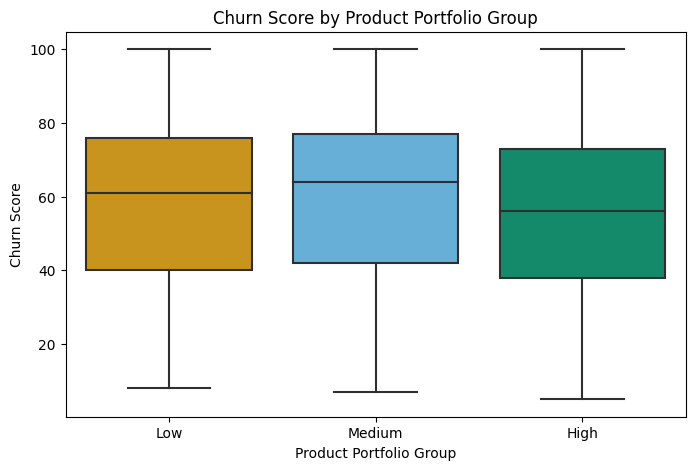

In [201]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="product_diversity",
    y="churn_score",
    data=df,
    order=["Low", "Medium", "High"]
)
plt.title("Churn Score by Product Portfolio Group")
plt.xlabel("Product Portfolio Group")
plt.ylabel("Churn Score")
plt.show()

This box plot compares churn scores across the product diversity groups. While they are broadly similar with no obvious outliers, there are visible differences in the distribution. 

The wide distribution of each category suggests there is no strict pattern that customers follow, suggesting that product diversity alone is likely not enough to fully explain churn risk. However the subtle differences between the groups, e.g. 'high' customers having a slightly lower average churn risk, confirms that an ANOVA test would likely be a useful insight into whether there is a statistical significance between the groups.

### Section 4d: Box Plot of CLTV by Portfolio Group

This chart compares customer lifetime value across product portfolio groups. Although CLTV is not the dependent variable in the main ANOVA, it provides useful business context by showing whether customers with broader portfolios also appear to represent greater commercial value.

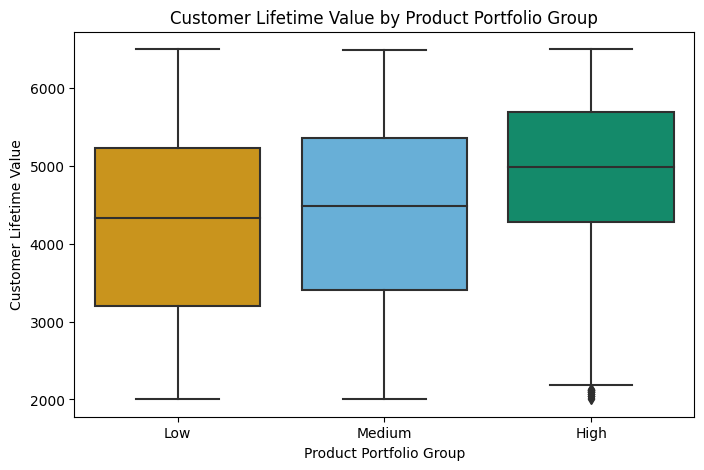

In [202]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="product_diversity",
    y="cltv",
    data=df,
    order=["Low", "Medium", "High"]
)
plt.title("Customer Lifetime Value by Product Portfolio Group")
plt.xlabel("Product Portfolio Group")
plt.ylabel("Customer Lifetime Value")
plt.show()

As we saw above, product diversity may not be the only driver of customer behaviour. To gain additional commerical context, customer lifetime value (cltv) is examined in the grpah above. It sugests that customers in the High group are more likely to have a higher cltv (most likely as they;re purchasing more products, but suggesting that some form of discounting may have been applied). This suggests that these more diverse customers could be higher-value and therefore more important to retain, but again, other factors would most likely impact churn.

### Section 4e: Geographic Distribution of Customers by Product Diversity

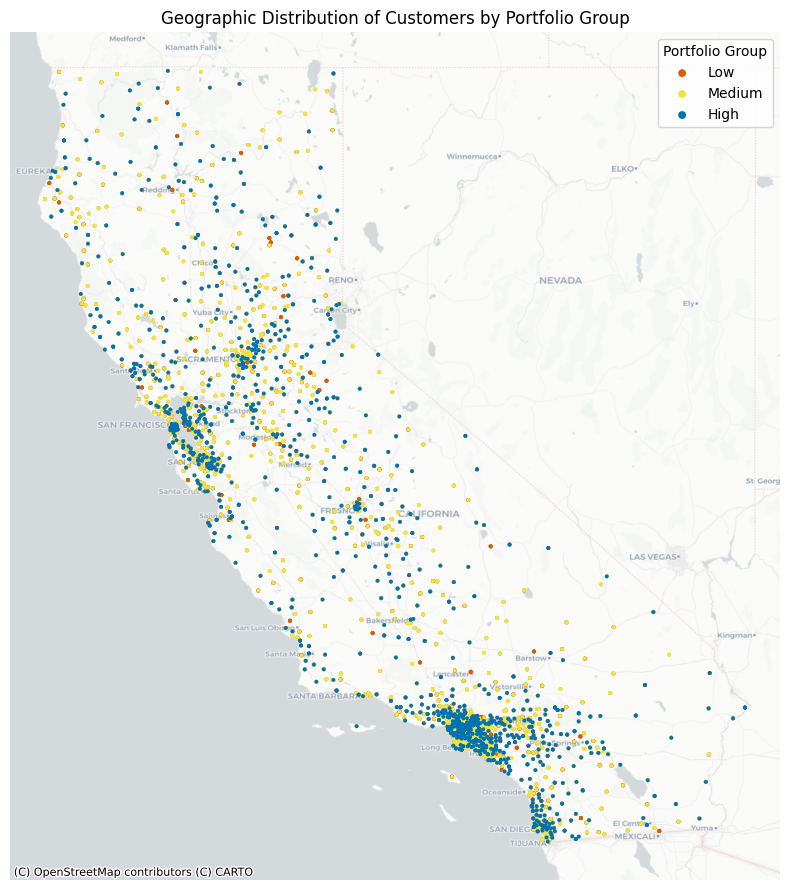

In [203]:
import geopandas as gpd
import contextily as ctx

# Build a GeoDataFrame from the lat/lon columns
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

palette = {
    "Low":    "#D55E00",
    "Medium": "#F0E442",
    "High":   "#0072B2"
}

fig, ax = plt.subplots(figsize=(8, 9))

for group in ["Low", "Medium", "High"]:
    subset = gdf[gdf["product_diversity"] == group]
    ax.scatter(
        subset.geometry.x,
        subset.geometry.y,
        color=palette[group],
        s=8,
        alpha=1,
        label=group,
        edgecolors="none"
    )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7)

ax.set_title("Geographic Distribution of Customers by Portfolio Group")
ax.set_axis_off()
ax.legend(title="Portfolio Group", markerscale=2)
plt.tight_layout()
plt.show()

This map above shows the locations of customers across Califoria, coloured by their product diversity. We see visible clustering around the more urban areas of the state (Sacramento, San Fransisco, Los Angeles and San Diego), but there is no strict concentration of product diversity groups in this area.

The only exception to this is Los Angeles which seems to have a large amount of 'High' customers compared to the other groups. While outside of the scope of this ANOVA, it would be interesting to explore why this is, for example, is it due to the 'online culture' of LA, or simply due to a higher population density.

### Section 4f: Homogeneity of Variance

ANOVA assumes independence of observations, approximate normality of residuals and homogeneity of variance (Bühner, 2010), therefore the final check we need to do is to ensure homogeneity of variance using Levene's Test (Brown and Forsythe, 1974).

In [204]:
from scipy.stats import levene

low_group    = df.loc[df['product_diversity'] == 'Low',    'churn_score'].values
medium_group = df.loc[df['product_diversity'] == 'Medium', 'churn_score'].values
high_group   = df.loc[df['product_diversity'] == 'High',   'churn_score'].values

stat, p = levene(
    low_group,
    medium_group,
    high_group
)

print(f"Levene Statistic = {stat:.4f}")
print(f"p-value = {p:.4f}")

Levene Statistic = 2.7503
p-value = 0.0640


The Levene's test result (W = 2.75, p = 0.064) indicates that the assumption of homogeneity of variance is satisfied at the 5% significance level. The variances of churn score across the Low, Medium, and High product diversity groups are not significantly different, confirming that one-way ANOVA is an appropriate test for this data.

### EDA Conclusion

In this section we constructed and assessed the suitability of the independent and dependent variables of this ANOVA, as well as exploring the wider business context in terms of customer value.

This EDA confirms that churn score is the correct dependent variable to use as it provides a continous measure of churn risk, which is suffiently varied. Having product diverity as the independent variable is also sensible as we are able to clearly classify the customer population which provides the basis for our ANOVA structure going forward.

Exploring these relationship to these two variables initally has shown some minor differences which requre formal statistical testing using ANOVA to confirm.

The EDA has also highlighted potential future analysis for assessing customer value both in terms of monetary value and influence, however these are outside the scope of this project.

Overall the EDA has confirmed that the dataset is suitable for further analysis and ANOVA testing.

# Section 5: Manually Calculated ANOVA

In the section below, we will manually calculate ANOVA (i.e. not use available libraries). The steps undertaken in this section have been informed by the Datacamp guide on the subject (Datacamp, 2024).

### Section 5a: Extract groups

First, we extract the churn_score values for each product_diversity group (Low, Medium, High). All subsequent calculations operate only on these three arrays.

In [205]:
# Extract churn_score for each product_diversity group
group_low    = df.loc[df['product_diversity'] == 'Low',    'churn_score'].values
group_medium = df.loc[df['product_diversity'] == 'Medium', 'churn_score'].values
group_high   = df.loc[df['product_diversity'] == 'High',   'churn_score'].values

groups = {'Low': group_low, 'Medium': group_medium, 'High': group_high}

for name, g in groups.items():
    print(f"{name:8s}  n={len(g):4d}  mean={g.mean():.4f}  var={g.var(ddof=1):.4f}")

Low       n=2969  mean=58.6746  var=462.5814
Medium    n=2795  mean=60.0340  var=475.5518
High      n=1279  mean=55.8405  var=427.0043


### Section 5b: Grand mean

The grand mean $\bar{X}_{..}$ is the mean of **all** observations across every group combined.

In [206]:
import numpy as np

all_scores = np.concatenate(list(groups.values()))
N = len(all_scores)           # total number of observations
k = len(groups)               # number of groups

grand_mean = all_scores.mean()
print(f"Grand mean  (X̄..) = {grand_mean:.4f}")
print(f"Total observations N = {N}")
print(f"Number of groups   k = {k}")

Grand mean  (X̄..) = 58.6994
Total observations N = 7043
Number of groups   k = 3


### Section 5c: Sum of Squares

One-way ANOVA partitions total variance into two components:

$$SS_{\text{between}} = \sum_{j=1}^{k} n_j (\bar{X}_{j} - \bar{X}_{..})^2$$

$$SS_{\text{within}} = \sum_{j=1}^{k} \sum_{i=1}^{n_j} (X_{ij} - \bar{X}_{j})^2$$

$$SS_{\text{total}} = SS_{\text{between}} + SS_{\text{within}}$$

- $SS_{\text{between}}$ (Between-Group SS) measures variance due to the grouping factor.
- $SS_{\text{within}}$ (Within-Group SS / Error SS) measures variance within each group (unexplained noise).

In [207]:
# Between-group sum of squares
SS_between = sum(
    len(g) * (g.mean() - grand_mean) ** 2
    for g in groups.values()
)

# Within-group sum of squares
SS_within = sum(
    ((g - g.mean()) ** 2).sum()
    for g in groups.values()
)

SS_total = SS_between + SS_within

print(f"SS_between = {SS_between:.4f}")
print(f"SS_within  = {SS_within:.4f}")
print(f"SS_total   = {SS_total:.4f}")

SS_between = 15433.7343
SS_within  = 3247344.9333
SS_total   = 3262778.6676


### Section 5d: Degrees of Freedom

$$df_{\text{between}} = k - 1$$

$$df_{\text{within}} = N - k$$

$$df_{\text{total}} = N - 1$$

In [208]:
df_between = k - 1
df_within  = N - k
df_total   = N - 1

print(f"df_between = {df_between}")
print(f"df_within  = {df_within}")
print(f"df_total   = {df_total}")

df_between = 2
df_within  = 7040
df_total   = 7042


### Section 5e: Mean Squares

Mean Squares are obtained by dividing each Sum of Squares by its corresponding degrees of freedom:

$$MS_{\text{between}} = \frac{SS_{\text{between}}}{df_{\text{between}}}$$

$$MS_{\text{within}} = \frac{SS_{\text{within}}}{df_{\text{within}}}$$

In [209]:
MS_between = SS_between / df_between
MS_within  = SS_within  / df_within

print(f"MS_between = {MS_between:.4f}")
print(f"MS_within  = {MS_within:.4f}")

MS_between = 7716.8671
MS_within  = 461.2706


### Section 5f: F-Statistic

The F-statistic is the ratio of between-group variance to within-group variance:

$$F = \frac{MS_{\text{between}}}{MS_{\text{within}}}$$

A large F value indicates that the group means differ more than would be expected by chance alone.

In [210]:
F_statistic = MS_between / MS_within
print(f"F-statistic = {F_statistic:.4f}")

F-statistic = 16.7296


### Section 5g: p-value and Critical Value

The p-value is the probability of observing an F-statistic this large (or larger) under the null hypothesis that all group means are equal. We use scipy.stats.f to evaluate the F-distribution CDF:

$$p = P(F_{df_{\text{between}},\, df_{\text{within}}} \geq F_{\text{observed}})$$

We also compute the critical value at $\alpha = 0.05$.

In [211]:
alpha = 0.05

# p-value: area in the right tail of the F-distribution
p_value = 1 - stats.f.cdf(F_statistic, dfn=df_between, dfd=df_within)

# Critical value at alpha = 0.05
F_critical = stats.f.ppf(1 - alpha, dfn=df_between, dfd=df_within)

print(f"F-statistic  = {F_statistic:.4f}")
print(f"F-critical   = {F_critical:.4f}  (α = {alpha})")
print(f"p-value      = {p_value:.2e}")

F-statistic  = 16.7296
F-critical   = 2.9970  (α = 0.05)
p-value      = 5.64e-08


### Section 5h: ANOVA Summary Table

Collating all values into a standard ANOVA table for clarity.

In [212]:
anova_table = pd.DataFrame({
    'Source':      ['Between Groups (product_diversity)', 'Within Groups (Error)', 'Total'],
    'SS':          [round(SS_between, 4), round(SS_within, 4), round(SS_total, 4)],
    'df':          [df_between, df_within, df_total],
    'MS':          [round(MS_between, 4), round(MS_within, 4), ''],
    'F':           [round(F_statistic, 4), '', ''],
    'p-value':     [f"{p_value:.2e}", '', ''],
})

anova_table

,Source,SS,df,MS,F,p-value
0,Between Groups (product_diversity),1.543373e+04,2,7716.8671,16.7296,5.64e-08
1,Within Groups (Error),3.247345e+06,7040,461.2706,,
2,Total,3.262779e+06,7042,,,


### Section 5i: Interpretation

Based on the results above:

- If $F > F_{\text{critical}}$ (equivalently, $p < 0.05$), we reject $H_0$ and conclude that at least one product diversity group has a significantly different mean churn score.
- If $F \leq F_{\text{critical}}$ ($p \geq 0.05$), we fail to reject $H_0$, meaning there is insufficient evidence that product diversity group affects churn score.

In [213]:
if p_value < alpha:
    print(f"Result: REJECT H₀  (F={F_statistic:.4f} > F_crit={F_critical:.4f}, p={p_value:.2e} < {alpha})")
    print("Conclusion: There is a statistically significant difference in mean churn score")
    print("            across product diversity groups (Low, Medium, High).")
else:
    print(f"Result: FAIL TO REJECT H₀  (F={F_statistic:.4f} ≤ F_crit={F_critical:.4f}, p={p_value:.2e} ≥ {alpha})")
    print("Conclusion: There is no statistically significant difference in mean churn score")
    print("            across product diversity groups (Low, Medium, High).")

Result: REJECT H₀  (F=16.7296 > F_crit=2.9970, p=5.64e-08 < 0.05)
Conclusion: There is a statistically significant difference in mean churn score
            across product diversity groups (Low, Medium, High).


To explore this further, Tukey's HSD is calculated below to understand which specific groups differ when compared (Tukey, 1991).

In [214]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["churn_score"],
    groups=df["product_diversity"],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
  High    Low   2.8341 0.0002 1.1502 4.5181   True
  High Medium   4.1935    0.0 2.4939 5.8931   True
   Low Medium   1.3594 0.0432 0.0325 2.6863   True
--------------------------------------------------


The table above shows us that each group is statistically significant from each other, however it is important to note that low-medium is only just significantly different p = 0.0432, which is expected considering their relative similarity in earlier EDA.

## Section 6: Using the ANOVA library

In this section we repeat the same one-way ANOVA using two standard library functions, scipy.stats.f_oneway and statsmodels, and then compare the results directly against the manually computed values from Section 5.

### Section 6a: scipy.stats.f_oneway

scipy.stats.f_oneway takes the raw group arrays and returns the F-statistic and p-value directly (SciPy, 2026).

In [215]:
from scipy import stats

F_scipy, p_scipy = stats.f_oneway(group_low, group_medium, group_high)

print(f"scipy  F-statistic = {F_scipy:.4f}")
print(f"scipy  p-value     = {p_scipy:.6f}")

scipy  F-statistic = 16.7296
scipy  p-value     = 0.000000


### Section 6b: statsmodels OLS + anova_lm

statsmodels fits the equivalent linear model $y = \mu + \tau_j + \varepsilon$ and returns a full ANOVA table including SS, df, MS, F, and p-valu (statsmodel, 2025), the same columns as the manual table in Section 5.

In [216]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# statsmodels requires a plain string category, not a pandas Categorical
model_df = df[['churn_score', 'product_diversity']].copy()
model_df['product_diversity'] = model_df['product_diversity'].astype(str)

model   = ols('churn_score ~ C(product_diversity)', data=model_df).fit()
anova_sm = sm.stats.anova_lm(model, typ=1)
anova_sm

,df,sum_sq,mean_sq,F,PR(>F)
C(product_diversity),2.0,1.543373e+04,7716.867139,16.729589,5.644729e-08
Residual,7040.0,3.247345e+06,461.270587,NaN,NaN


### Comparison: Manual vs Library

Placing the key values side by side to confirm both approaches give the same answer.

In [217]:
comparison = pd.DataFrame({
    'Method':      ['Manual (Section 5)', 'scipy.stats.f_oneway', 'statsmodels anova_lm'],
    'F-statistic': [
        round(F_statistic, 4),
        round(F_scipy, 4),
        round(anova_sm.loc['C(product_diversity)', 'F'], 4)
    ],
    'p-value': [
    f"{p_value:.2e}",
    f"{p_scipy:.2e}",
    f"{anova_sm.loc['C(product_diversity)', 'PR(>F)']:.2e}"
    ],
})

comparison

,Method,F-statistic,p-value
0,Manual (Section 5),16.7296,5.64e-08
1,scipy.stats.f_oneway,16.7296,5.64e-08
2,statsmodels anova_lm,16.7296,5.64e-08


All three methods produce identical F-statistics and p-values, confirming that the manual calculations in Section 5 are correct.

## Section 7: Practical Significance

The work in sections 5 and 6 demonstrate that there is a statistical significance in mean churn score across the three product diversity groups, however the EDA section showed that there are other factors that could have an impact on churn score. To assess the practical impact of product diversity on churn score, eta squared (η²) is calculated in the section below.

η² measures the proportion of total variance in churn score that is explained by group membership (product diversity). It is defined as:

$$\eta^2 = \frac{SS_{\text{between}}}{SS_{\text{total}}}$$

Conventional benchmarks (Cohen, 1988) for interpreting η² are:

| η² | Effect size |
|---|---|
| 0.01 | Small |
| 0.06 | Medium |
| 0.14 | Large |

In [218]:
eta_squared = SS_between / SS_total

print(f"SS_between = {SS_between:.4f}")
print(f"SS_total   = {SS_total:.4f}")
print(f"η²         = {eta_squared:.4f}  ({eta_squared*100:.2f}% of variance explained)")

if eta_squared < 0.01:
    label = "negligible"
elif eta_squared < 0.06:
    label = "small"
elif eta_squared < 0.14:
    label = "medium"
else:
    label = "large"

print(f"Effect size: {label}")

SS_between = 15433.7343
SS_total   = 3262778.6676
η²         = 0.0047  (0.47% of variance explained)
Effect size: negligible


### Interpretation

While the ANOVA in Sections 5 and 6 confirmed a statistically significant difference between groups (p < 0.05), η² quantifies how much of the variation in churn score is actually attributable to product diversity. A small η² indicates that although the effect is real, product diversity alone is a weak predictor of churn risk — consistent with the overlapping distributions observed in the EDA box plots. Other factors not captured by this grouping are likely responsible for the majority of variance in churn score.

## Section 8: References

Brown, M.B. and Forsythe, A.B. (1974) Robust Tests for the Equality of Variances, Journal of the American Statistical Association, 69(346), pp 364-367 [Online] Available at: https://www.jstor.org/stable/2285659 (Accessed 31st July 2026)

Bühner, M. (2010) 'Is it really robust? Reinvestigating the robustness of ANOVA against violations of the normal distribution assumption'. Methodology: European Journal of Research Methods for the Behavioral and Social Sciences, 6(4), pp 147-151. https://doi.org/10.1027/1614-2241/A000016 (Accessed 31st July 2026)

Cohen, J. (1988) Statistical Power Analysis for the Behavioral Sciences [Online] 2nd Edition, Psycology Press, New York. Available at: https://www.taylorfrancis.com/books/mono/10.4324/9780203771587/statistical-power-analysis-behavioral-sciences-jacob-cohen (Accessed 7th August 2026)

Datacamp (2024) ANOVA Test: An In-Depth Guide with Examples. [Online] Available at: https://www.datacamp.com/tutorial/anova-test (Accessed 7th August 2026)

SciPy (2026) f_oneway [Online]. Available at: https://docs.scipy.org/doc/scipy-1.18.0/reference/generated/scipy.stats.f_oneway.html (Accessed 7th August 2026)

Siegal Lab (n.d.) Color Palette [Online] Available at: https://siegal.bio.nyu.edu/color-palette/ (Accessed 31st July 2026)

Statsmodels (2025) statsmodels.stats.anova.anova_lm [Online] Available at: https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html (Accessed 7th August 2026)

Tukey, J.W. (1991) The Philosophy of Multiple Comparisons, Statistical Science, 6(1), pp 100-116 [Online] Available at: https://www.jstor.org/stable/2245714 (Accessed 7th August 2026)